## TASK-1

## Subtask 1.1: Data Acquisition and Train-Test Splits for Classification

import warnings

In [45]:
warnings.filterwarnings("ignore")

In [46]:
import pandas as pd

In [47]:
from sklearn.model_selection import train_test_split

In [48]:
pima_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

In [49]:
pima_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

In [50]:
pima_df = pd.read_csv(pima_url, header=None, names=pima_cols)

In [51]:
X_pima = pima_df[pima_cols[:-1]]

In [52]:
y_pima = pima_df['Outcome']

In [53]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_pima, y_pima, test_size=0.20, stratify=y_pima, random_state=42
)

In [54]:
print("Pima Classification Training Set Shape:", X_train_c.shape)

Pima Classification Training Set Shape: (614, 8)


In [55]:
print("Pima Classification Test Set Shape:", X_test_c.shape)


Pima Classification Test Set Shape: (154, 8)


## Subtask 1.2: Constructing the Decision Tree Classifier

In [58]:
from sklearn.tree import DecisionTreeClassifier

In [59]:
from sklearn.metrics import accuracy_score, classification_report

In [60]:
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)

In [61]:
tree_clf.fit(X_train_c, y_train_c)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [62]:
clf_preds = tree_clf.predict(X_test_c)

In [63]:
print(f"Decision Tree Classifier Test Accuracy: {accuracy_score(y_test_c, clf_preds) * 100:.2f}%\n")

Decision Tree Classifier Test Accuracy: 79.87%



In [64]:
print("--- Classification Report ---")

--- Classification Report ---


In [65]:
print(classification_report(y_test_c, clf_preds, target_names=['No Diabetes (0)', 'Diabetes (1)']))

                 precision    recall  f1-score   support

No Diabetes (0)       0.82      0.88      0.85       100
   Diabetes (1)       0.74      0.65      0.69        54

       accuracy                           0.80       154
      macro avg       0.78      0.76      0.77       154
   weighted avg       0.80      0.80      0.80       154



## Subtask 1.3: Visualizing the Trained Decision Tree Structure

In [67]:
import matplotlib.pyplot as plt

In [68]:
from sklearn.tree import plot_tree

In [69]:
plt.figure(figsize=(15, 8))

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

[Text(0.5125, 0.9, 'Glucose <= 154.5\ngini = 0.454\nsamples = 614\nvalue = [400, 214]\nclass = No Diabetes'),
 Text(0.275, 0.7, 'BMI <= 27.35\ngini = 0.379\nsamples = 515\nvalue = [384, 131]\nclass = No Diabetes'),
 Text(0.39375, 0.8, 'True  '),
 Text(0.15, 0.5, 'Glucose <= 151.5\ngini = 0.097\nsamples = 137\nvalue = [130, 7]\nclass = No Diabetes'),
 Text(0.1, 0.3, 'BMI <= 9.1\ngini = 0.084\nsamples = 136\nvalue = [130, 6]\nclass = No Diabetes'),
 Text(0.05, 0.1, 'gini = 0.346\nsamples = 9\nvalue = [7, 2]\nclass = No Diabetes'),
 Text(0.15, 0.1, 'gini = 0.061\nsamples = 127\nvalue = [123, 4]\nclass = No Diabetes'),
 Text(0.2, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = Diabetes'),
 Text(0.4, 0.5, 'Age <= 30.5\ngini = 0.441\nsamples = 378\nvalue = [254, 124]\nclass = No Diabetes'),
 Text(0.3, 0.3, 'Glucose <= 127.5\ngini = 0.332\nsamples = 205\nvalue = [162, 43]\nclass = No Diabetes'),
 Text(0.25, 0.1, 'gini = 0.238\nsamples = 159\nvalue = [137, 22]\nclass = No Diabetes'),
 T

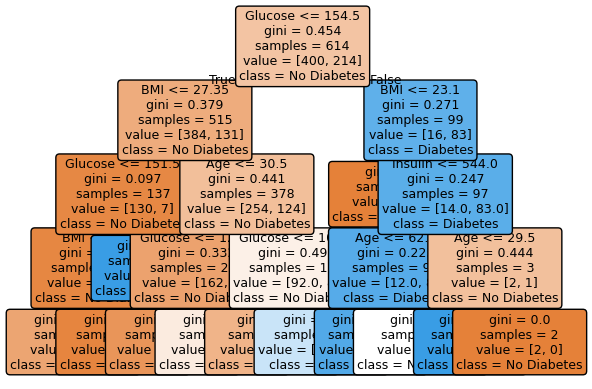

In [71]:
plot_tree(
    tree_clf, 
    feature_names=pima_cols[:-1], 
    class_names=['No Diabetes', 'Diabetes'], 
    filled=True, 
    rounded=True, 
    fontsize=9
)

Text(0.5, 1.0, 'Decision Tree Classifier Structure (Max Depth = 4)')

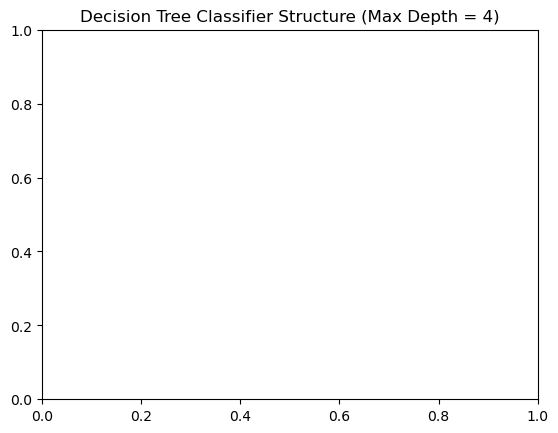

In [72]:
plt.title("Decision Tree Classifier Structure (Max Depth = 4)")

In [73]:
plt.show()

## Subtask 1.4: Constructing a Decision Tree Regressor

In [74]:
from sklearn.tree import DecisionTreeRegressor

In [75]:
from sklearn.preprocessing import StandardScaler

In [76]:
boston_url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

In [79]:
boston_df = pd.read_csv(boston_url)

In [82]:
boston_features = [col for col in boston_df.columns if col != 'medv']

In [83]:
X_boston = boston_df[boston_features]

In [84]:
y_boston = boston_df['medv']

In [85]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_boston, y_boston, test_size=0.20, random_state=42)

In [86]:
scaler_r = StandardScaler()

In [87]:
X_train_r_scaled = scaler_r.fit_transform(X_train_r)

In [88]:
X_test_r_scaled = scaler_r.transform(X_test_r)

In [89]:
tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)

In [90]:
tree_reg.fit(X_train_r_scaled, y_train_r)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [91]:
print("Decision Tree Regressor trained successfully. Max Depth set to 5.")

Decision Tree Regressor trained successfully. Max Depth set to 5.


## Subtask 1.5: Evaluating Decision Tree Regressor Predictions

In [92]:
from sklearn.metrics import mean_squared_error, r2_score

In [93]:
import numpy as np


In [94]:
reg_preds = tree_reg.predict(X_test_r_scaled)

In [95]:
mse_val = mean_squared_error(y_test_r, reg_preds)

In [96]:
rmse_val = np.sqrt(mse_val)

In [97]:
r2_val = r2_score(y_test_r, reg_preds)

In [98]:
print(f"Mean Squared Error (MSE): {mse_val:.4f}")

Mean Squared Error (MSE): 8.5539


In [99]:
print(f"Root Mean Squared Error (RMSE): {rmse_val:.4f} ($1000s)")

Root Mean Squared Error (RMSE): 2.9247 ($1000s)


In [100]:
print(f"R2 Coefficient of Determination: {r2_val:.4f}\n")

R2 Coefficient of Determination: 0.8834



In [101]:
plt.figure(figsize=(6, 4))

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

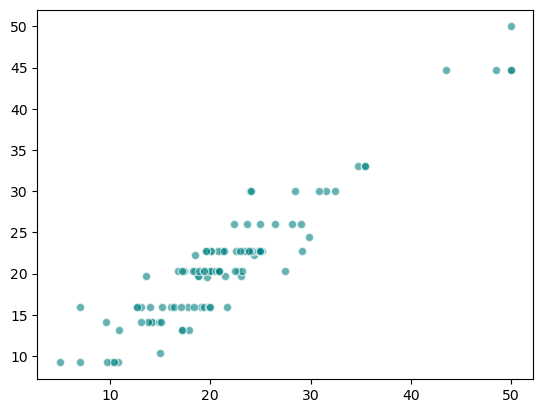

In [102]:
plt.scatter(y_test_r, reg_preds, color='teal', alpha=0.6, edgecolor='white')

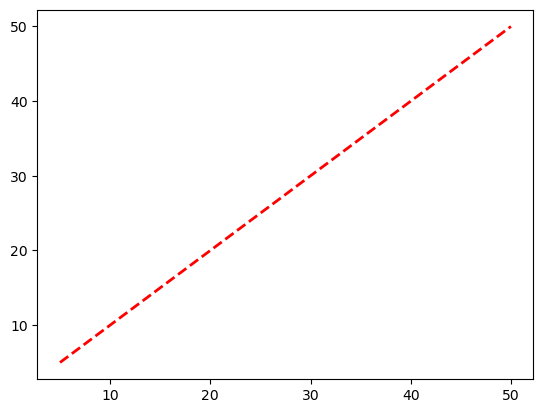

In [103]:
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2, label='Perfect Prediction')

Text(0.5, 1.0, 'Decision Tree Regressor: Actual vs. Predicted')

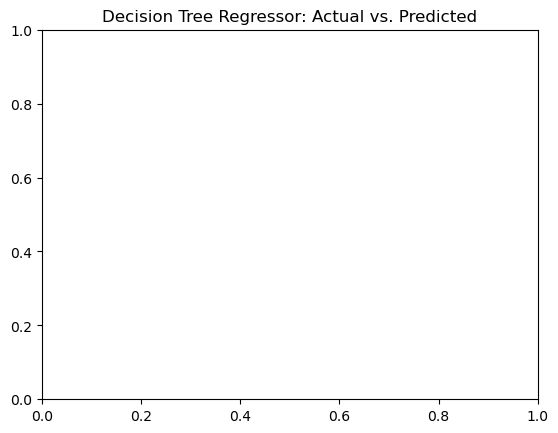

In [104]:
plt.title("Decision Tree Regressor: Actual vs. Predicted")

Text(0.5, 0, 'Actual Home Value (MEDV)')

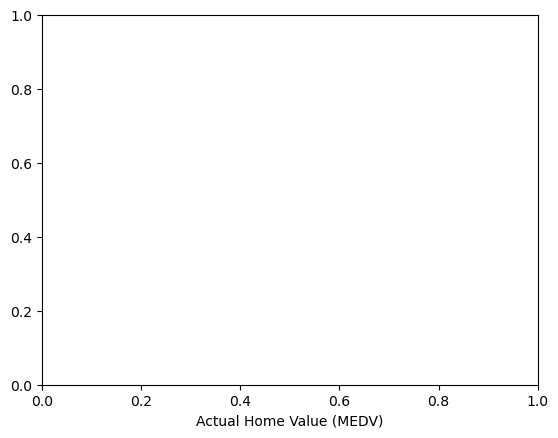

In [105]:
plt.xlabel("Actual Home Value (MEDV)")

Text(0, 0.5, 'Predicted Home Value (MEDV)')

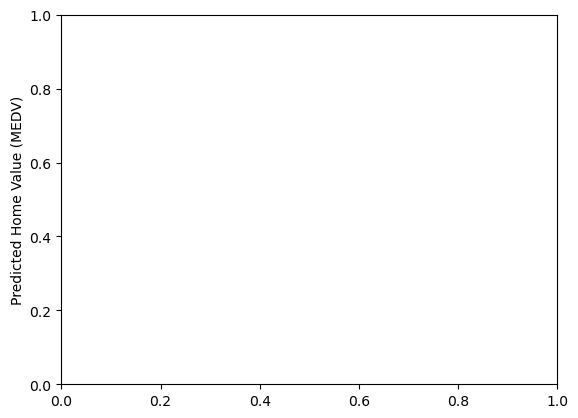

In [106]:
plt.ylabel("Predicted Home Value (MEDV)")

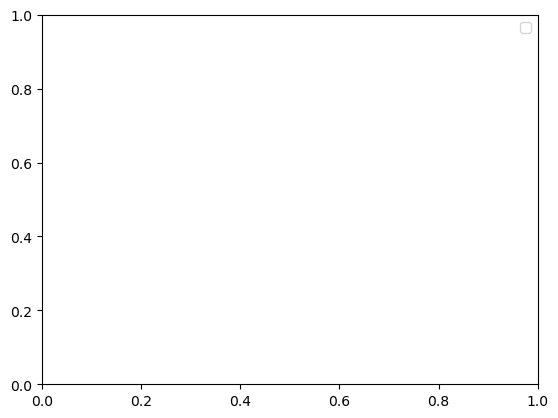

In [107]:
plt.legend()

In [108]:
plt.show()

## TASK-2

## Subtask 2.1: Standard Scaling and High-Dimensional Target Map

In [109]:
import warnings

In [110]:
warnings.filterwarnings("ignore")

In [111]:
import pandas as pd

In [112]:
from sklearn.model_selection import train_test_split

In [113]:
from sklearn.preprocessing import StandardScaler

In [114]:
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"

In [115]:
sonar_features = [f"F_{i}" for i in range(1, 61)]

In [116]:
sonar_columns = sonar_features + ['Class']

In [118]:
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)

In [119]:
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})

In [120]:
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})

In [121]:
X_sonar = sonar_df[sonar_features]

In [122]:
y_sonar = sonar_df['Class_numeric']

In [123]:
scaler_sonar = StandardScaler()

In [124]:
X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)

In [125]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sonar_scaled, y_sonar, test_size=0.30, stratify=y_sonar, random_state=42
)

In [126]:
print("Sonar Training Set Shape:", X_train_s.shape)

Sonar Training Set Shape: (145, 60)


In [127]:
print("Sonar Test Set Shape:", X_test_s.shape)

Sonar Test Set Shape: (63, 60)


## Subtask 2.2: Implementing a Bagging Classifier

In [128]:
from sklearn.ensemble import BaggingClassifier

In [129]:
from sklearn.metrics import accuracy_score

In [131]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

In [132]:
bagging_model.fit(X_train_s, y_train_s)

,estimator,DecisionTreeC...ndom_state=42)
,n_estimators,50
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,-1
,random_state,42
,verbose,0


In [133]:
bagging_preds = bagging_model.predict(X_test_s)

In [134]:
bagging_accuracy = accuracy_score(y_test_s, bagging_preds)

In [135]:
print(f"Bagging Classifier Test Accuracy: {bagging_accuracy * 100:.2f}%")

Bagging Classifier Test Accuracy: 80.95%


## Subtask 2.3: Implementing a Random Forest Classifier

In [136]:
from sklearn.ensemble import RandomForestClassifier

In [137]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

In [138]:
rf_model.fit(X_train_s, y_train_s)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [139]:
rf_preds = rf_model.predict(X_test_s)

In [140]:
rf_accuracy = accuracy_score(y_test_s, rf_preds)

In [141]:
print(f"Random Forest Classifier Test Accuracy: {rf_accuracy * 100:.2f}%")

Random Forest Classifier Test Accuracy: 82.54%


## Subtask 2.4: Implementing a Voting Ensemble Classifier

In [142]:
from sklearn.ensemble import VotingClassifier

In [143]:
from sklearn.linear_model import LogisticRegression

In [144]:
from sklearn.svm import SVC

In [145]:
estimators = [
    ('lr', LogisticRegression(max_iter=500, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
]

In [146]:
voting_model = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)

In [147]:
voting_model.fit(X_train_s, y_train_s)

,estimators,"[('lr', ...), ('dt', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,-1
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [148]:
voting_preds = voting_model.predict(X_test_s)

In [149]:
voting_accuracy = accuracy_score(y_test_s, voting_preds)

In [150]:
print(f"Voting Classifier Test Accuracy: {voting_accuracy * 100:.2f}%")

Voting Classifier Test Accuracy: 87.30%


## Subtask 2.5: Performance Comparison of Ensemble Techniques

In [151]:
import matplotlib.pyplot as plt

In [152]:
import seaborn as sns

In [153]:
ensemble_results = pd.DataFrame({
    'Ensemble Technique': ['Bagging (DT Base)', 'Random Forest', 'Voting Classifier (Soft)'],
    'Test Accuracy (%)': [bagging_accuracy * 100, rf_accuracy * 100, voting_accuracy * 100]
})

In [154]:
print("--- Performance Comparison ---")

--- Performance Comparison ---


In [155]:
print(ensemble_results.to_string(index=False))

      Ensemble Technique  Test Accuracy (%)
       Bagging (DT Base)          80.952381
           Random Forest          82.539683
Voting Classifier (Soft)          87.301587


In [156]:
plt.figure(figsize=(6, 4))

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='Test Accuracy (%)', ylabel='Ensemble Technique'>

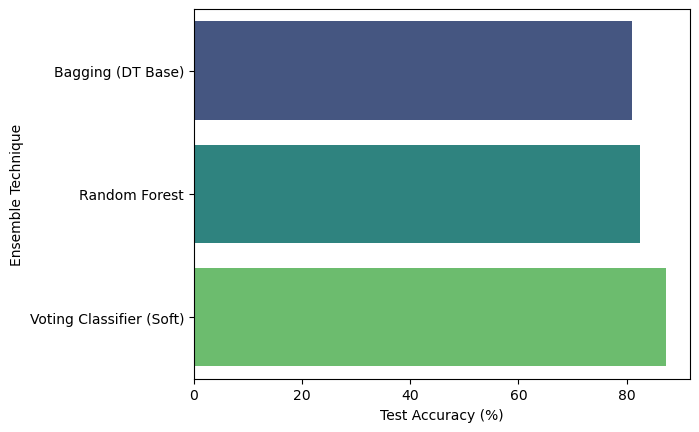

In [157]:
sns.barplot(data=ensemble_results, x='Test Accuracy (%)', y='Ensemble Technique', palette='viridis')

(50.0, 100.0)

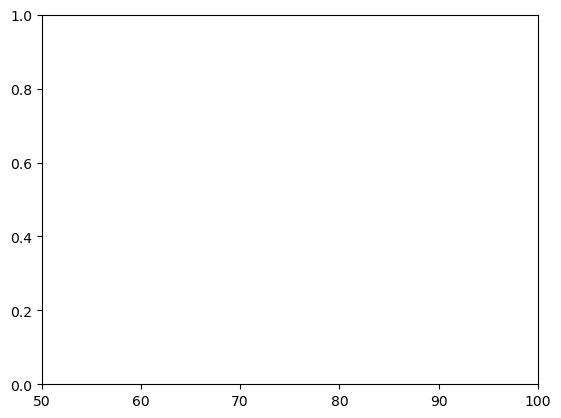

In [159]:
plt.xlim([50, 100])

Text(0.5, 1.0, 'Ensemble Models Accuracy Comparison')

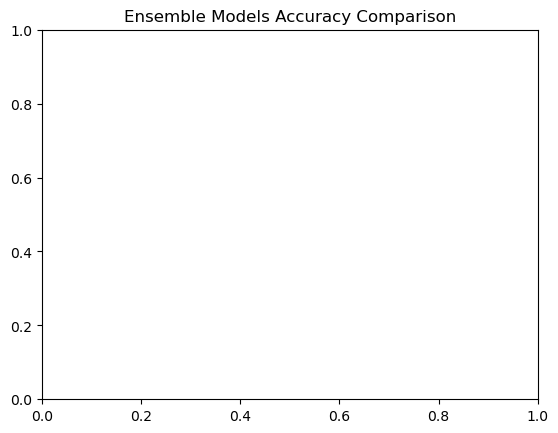

In [160]:
plt.title("Ensemble Models Accuracy Comparison")

In [161]:
plt.show()

## TASK-3

## Subtask 3.1: Implementing the AdaBoost Classifier

In [163]:
import warnings

In [164]:
warnings.filterwarnings("ignore")

In [165]:
from sklearn.ensemble import AdaBoostClassifier

In [166]:
from sklearn.metrics import accuracy_score

In [167]:
adaboost_model = AdaBoostClassifier(n_estimators=50, random_state=42)

In [169]:
adaboost_model.fit(X_train_s, y_train_s)

,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,42


In [170]:
ada_preds = adaboost_model.predict(X_test_s)

In [171]:
ada_accuracy = accuracy_score(y_test_s, ada_preds)

In [172]:
print(f"AdaBoost Classifier Test Accuracy: {ada_accuracy * 100:.2f}%")

AdaBoost Classifier Test Accuracy: 85.71%


## Subtask 3.2: Implementing the Gradient Boosting Classifier


In [173]:
from sklearn.ensemble import GradientBoostingClassifier

In [174]:
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)

In [175]:
gb_model.fit(X_train_s, y_train_s)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [176]:
gb_preds = gb_model.predict(X_test_s)

In [177]:
gb_accuracy = accuracy_score(y_test_s, gb_preds)

In [178]:
print(f"Gradient Boosting Classifier Test Accuracy: {gb_accuracy * 100:.2f}%")

Gradient Boosting Classifier Test Accuracy: 80.95%


## Subtask 3.3: Hyperparameter Tuning for Gradient Boosting Classifier

In [179]:
from sklearn.model_selection import GridSearchCV

In [180]:
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5]
}

In [181]:
grid_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

In [182]:
grid_gb.fit(X_train_s, y_train_s)

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [183]:
best_gb = grid_gb.best_estimator_

In [184]:
tuned_gb_preds = best_gb.predict(X_test_s)

In [185]:
tuned_gb_accuracy = accuracy_score(y_test_s, tuned_gb_preds)

In [186]:
print("Optimal Hyperparameters Selected:", grid_search_params := grid_gb.best_params_)

Optimal Hyperparameters Selected: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150}


In [187]:
print(f"Tuned Gradient Boosting Test Accuracy: {tuned_gb_accuracy * 100:.2f}%")

Tuned Gradient Boosting Test Accuracy: 79.37%


## Subtask 3.4: Master Comparison: Ensemble vs. Boosting Models

In [189]:
master_comparison = pd.DataFrame({
    'Model Classifier': [
        'Bagging Classifier', 
        'Random Forest Classifier', 
        'Voting Ensemble (Soft)', 
        'AdaBoost Classifier', 
        'Base Gradient Boosting', 
        'Tuned Gradient Boosting'
    ],
    'Accuracy (%)': [
        bagging_accuracy * 100, 
        rf_accuracy * 100, 
        voting_accuracy * 100, 
        ada_accuracy * 100, 
        gb_accuracy * 100, 
        tuned_gb_accuracy * 100
    ]
}).sort_values(by='Accuracy (%)', ascending=False)

In [190]:
print("--- Master Performance Table: Tasks 2 & 3 ---")

--- Master Performance Table: Tasks 2 & 3 ---


In [191]:
print(master_comparison.to_string(index=False))

        Model Classifier  Accuracy (%)
  Voting Ensemble (Soft)     87.301587
     AdaBoost Classifier     85.714286
Random Forest Classifier     82.539683
      Bagging Classifier     80.952381
  Base Gradient Boosting     80.952381
 Tuned Gradient Boosting     79.365079


## Subtask 3.5: Plotting Feature Importances (Random Forest vs. Tuned Gradient Boosting)


In [192]:
import matplotlib.pyplot as plt

In [193]:
import numpy as np

In [194]:
rf_importances = rf_model.feature_importances_

In [195]:
gb_importances = best_gb.feature_importances_

In [196]:
top_indices_rf = np.argsort(rf_importances)[-10:]

In [197]:
top_indices_gb = np.argsort(gb_importances)[-10:]

In [198]:
features_list = [f"F_{i}" for i in range(1, 61)]

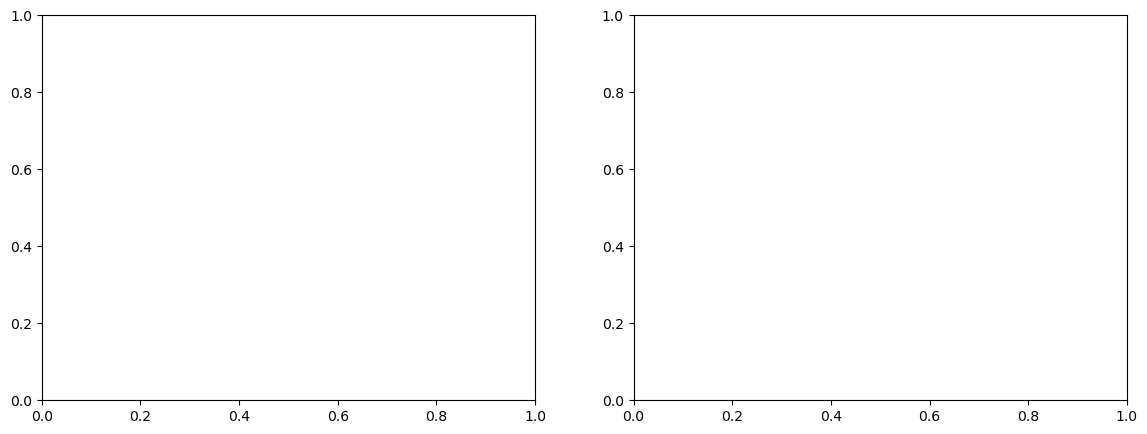

In [199]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

In [200]:
axes[0].barh(range(10), rf_importances[top_indices_rf], color='royalblue', align='center')

<BarContainer object of 10 artists>

In [201]:
axes[0].set_yticks(range(10))

In [202]:
axes[0].set_yticklabels([features_list[i] for i in top_indices_rf])

[Text(0, 0, 'F_1'),
 Text(0, 1, 'F_36'),
 Text(0, 2, 'F_49'),
 Text(0, 3, 'F_52'),
 Text(0, 4, 'F_12'),
 Text(0, 5, 'F_47'),
 Text(0, 6, 'F_48'),
 Text(0, 7, 'F_10'),
 Text(0, 8, 'F_11'),
 Text(0, 9, 'F_9')]

In [203]:
axes[0].set_title("Top 10 Feature Importances: Random Forest")

Text(0.5, 1.0, 'Top 10 Feature Importances: Random Forest')

In [204]:
axes[0].set_xlabel("Relative Importance")

Text(0.5, 4.444444444444445, 'Relative Importance')

In [205]:
axes[1].barh(range(10), gb_importances[top_indices_gb], color='darkorange', align='center')

<BarContainer object of 10 artists>

In [206]:
axes[1].set_yticks(range(10))

In [207]:
axes[1].set_yticklabels([features_list[i] for i in top_indices_gb])

[Text(0, 0, 'F_10'),
 Text(0, 1, 'F_48'),
 Text(0, 2, 'F_43'),
 Text(0, 3, 'F_17'),
 Text(0, 4, 'F_37'),
 Text(0, 5, 'F_47'),
 Text(0, 6, 'F_4'),
 Text(0, 7, 'F_28'),
 Text(0, 8, 'F_9'),
 Text(0, 9, 'F_11')]

In [208]:
axes[1].set_title("Top 10 Feature Importances: Tuned Gradient Boosting")

Text(0.5, 1.0, 'Top 10 Feature Importances: Tuned Gradient Boosting')

In [209]:
axes[1].set_xlabel("Relative Importance")

Text(0.5, 4.444444444444445, 'Relative Importance')

In [210]:
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [211]:
plt.show()

## POST LAB

## TASK-1 

In [212]:
# ==========================================
# POST LAB TASK
# TITANIC DATASET CLASSIFICATION
# ==========================================

# Import Libraries
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load Titanic Dataset
df = sns.load_dataset("titanic")

# Display first 5 rows
print(df.head())

# Select Required Features
df = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']]

# Handle Missing Values
imputer = SimpleImputer(strategy='most_frequent')
df[['age', 'embarked']] = imputer.fit_transform(df[['age', 'embarked']])

# Encode Categorical Columns
encoder = LabelEncoder()
df['sex'] = encoder.fit_transform(df['sex'])
df['embarked'] = encoder.fit_transform(df['embarked'])

# Features and Target
X = df.drop('survived', axis=1)
y = df['survived']

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create Decision Tree Classifier
model = DecisionTreeClassifier(random_state=42)

# Train the Model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Accuracy Score:
0.7653631284916201

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.78      0.80       105
           1       0.71      0.74      0.72       

## TASK-2

In [213]:
import pandas as pd

# Sample California Housing Dataset
data = {
    "MedInc": [8.3252, 8.3014, 7.2574, 5.6431, 3.8462,
               4.0368, 3.6591, 3.1200, 2.0804, 3.6912,
               3.2031, 3.2705, 3.0750, 2.6736, 1.9167,
               2.1250, 2.7750, 2.1202, 1.9911, 2.6033],

    "HouseAge": [41, 21, 52, 52, 52,
                 52, 52, 42, 52, 52,
                 42, 52, 52, 52, 52,
                 50, 52, 40, 34, 36],

    "AveRooms": [6.9841, 6.2381, 8.2881, 5.8174, 6.2819,
                 4.7617, 4.9319, 4.7975, 4.2941, 4.9706,
                 5.0806, 4.8345, 4.8269, 4.1200, 4.0541,
                 4.3214, 5.1120, 4.6789, 4.5023, 5.2101],

    "AveBedrms": [1.0238, 0.9719, 1.0734, 1.0731, 1.0811,
                  1.1036, 1.1036, 1.0248, 1.1176, 0.9902,
                  1.0200, 1.0800, 1.0650, 1.0900, 1.1200,
                  1.0300, 1.0400, 1.0500, 1.0600, 1.0100],

    "Population": [322, 2401, 496, 558, 565,
                   413, 1094, 1157, 1206, 1551,
                   980, 1100, 1400, 870, 920,
                   1010, 1230, 1125, 980, 1340],

    "AveOccup": [2.5556, 2.1098, 2.8023, 2.5479, 2.1815,
                 2.1399, 2.1284, 1.7883, 2.0269, 2.1723,
                 2.3000, 2.1200, 2.4500, 2.0100, 2.2200,
                 2.1800, 2.3600, 2.1400, 2.2700, 2.3100],

    "Latitude": [37.88, 37.86, 37.85, 37.85, 37.85,
                 37.85, 37.84, 37.84, 37.84, 37.84,
                 37.83, 37.83, 37.82, 37.82, 37.81,
                 37.81, 37.80, 37.80, 37.79, 37.79],

    "Longitude": [-122.23, -122.22, -122.24, -122.25, -122.25,
                  -122.25, -122.26, -122.26, -122.27, -122.27,
                  -122.28, -122.28, -122.29, -122.30, -122.30,
                  -122.31, -122.32, -122.33, -122.34, -122.35],

    "MedHouseVal": [4.526, 3.585, 3.521, 3.413, 3.422,
                    2.697, 2.992, 2.414, 2.267, 2.611,
                    2.450, 2.300, 2.100, 1.980, 1.850,
                    1.920, 2.050, 2.120, 1.990, 2.250]
}

# Create DataFrame
df = pd.DataFrame(data)

# Save as CSV
df.to_csv("california_housing_sample.csv", index=False)

print("CSV file created successfully!")

CSV file created successfully!


First 5 Rows of Dataset:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Regression Performance
-----------------------
Mean Absolute Error (MAE): 0.45467918846899225
Mean Squared Error (MSE): 0.495235205629094
R2 Score: 0.622075845135081

Actual vs Predicted (First 10 Rows):
    Actual  Predicted
0  0.47700    0.41400
1  0.45800    1.20300
2  5.00001    5.00001
3  2.18600    2.17000
4  2.78000    2.25700
5  1.58700    1.78700
6  1.98200    2.21700
7  1.57500    1.74000
8  3.40000    2.77200
9  

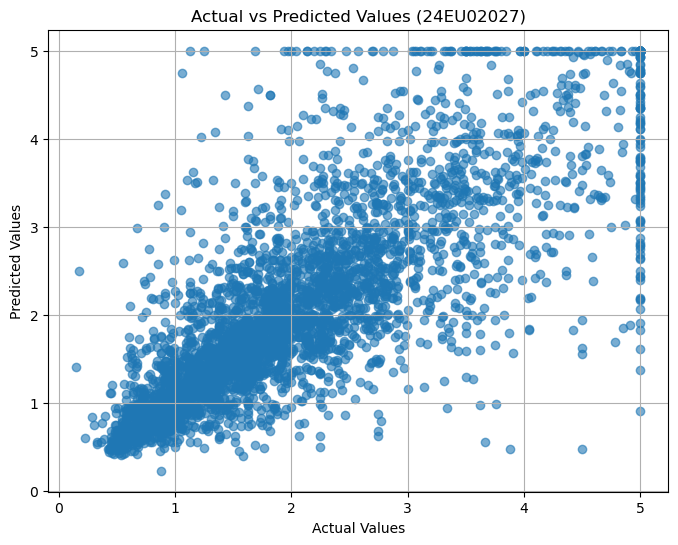

In [214]:
# ==========================================
# POST LAB TASK
# CALIFORNIA HOUSING DATASET REGRESSION
# ==========================================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load California Housing Dataset
housing = fetch_california_housing()

# Create DataFrame
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

# Display first 5 rows
print("First 5 Rows of Dataset:")
print(X.head())

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create Decision Tree Regressor
model = DecisionTreeRegressor(random_state=42)

# Train the Model
model.fit(X_train, y_train)

# Predict on Test Data
y_pred = model.predict(X_test)

# Evaluation Metrics
print("\nRegression Performance")
print("-----------------------")
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Actual vs Predicted Values
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print("\nActual vs Predicted (First 10 Rows):")
print(comparison.head(10))

# Scatter Plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (24EU02027)")
plt.grid(True)
plt.show()